# Neural Posterior Estimation for LISA
## Part 2a — extending to a wider prior with heterodyning and prior-conditioning

**AI for LISA Hackathon @ ESTEC — tutorial by Stephen Green (Tuesday)**

Part 1 built an amortized posterior estimator for a LISA galactic binary, but with a very narrow frequency prior. The frequency prior was narrow because we assumed a search had already run: over four years,
$\delta f \sim \mathcal{U}[\pm 10^{-7}\,{\rm Hz}]$ is $\pm 12.6$ cycles of winding, which is why
$N = 256$ samples of the complex envelope were enough.

Suppose we widen that prior by a factor $W$. The data grows, because the
envelope winds $W$ times faster and takes $W$ times more samples to represent. At the same time, the posterior is unchanged, but now inside a box $W$ times larger. Naive scaling of the prior is asking
the network to find a sharper needle in a bigger haystack from the same number of simulations.

The solution is not a bigger network. It is to stop asking the network to learn what you already
know. Given a *guess* $\widehat{\delta f}$ at the frequency, we can demodulate the data by it and
discard the bandwidth that guess made irrelevant. What is left is, exactly, Part 1's problem, so
Part 1's network solves it with **no additional training**. Scanning the guess across the wide
prior then performs search and parameter estimation in a single pass, and importance sampling turns
the output into an exact posterior with a quantified error bar attached.

DINGO-BNS uses the same trick, where prior-conditioning and demodulating by the model phase (heterodyning) enables 1-second inference for binary neutron stars.

<!-- ---

### Roadmap (about 22 minutes)

| | | |
|---|---|---|
| 1 | A wider prior | ~3 min |
| 2 | Naive NPE, and how it fails | ~5 min |
| 3 | Conditioning: demodulate and select a band | ~4 min |
| 4 | The frequency scan | ~5 min |
| 5 | Calibration: the P–P plot | ~3 min |
| 6 | Where this is used | ~2 min |
| 7 | Exercise and challenge | remainder / at home | -->

### Before you start

This notebook needs `checkpoints/part1_flow_v2.pt` — the flow you trained in Part 1 — and loads a
stored network for the section 7 exercise. Everything else is self-contained. The wide network in
section 2 trains live by default (`TRAIN_LIVE`, about 3 minutes on a T4 and 10 on a laptop CPU).

In [1]:
# Guarded so that this is a no-op where the packages already exist (e.g. a uv-managed venv,
# whose contents `uv sync` reconciles against the lockfile); on a bare Colab runtime it installs.
import importlib.util
import sys

if any(importlib.util.find_spec(pkg) is None for pkg in ("glasflow", "corner")):
    !{sys.executable} -m pip install -q glasflow corner

In [2]:
import os
import time

import corner
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy import stats
from torch import nn
from torch.utils.data import BatchSampler, DataLoader, Dataset, RandomSampler

from matplotlib.patches import ConnectionPatch

from glasflow.nflows import distributions, flows, transforms

# `mps` is deliberately excluded: nflows has known correctness problems on that backend.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

torch.manual_seed(0);

device: cpu


---
# 1. A wider prior

<!-- *(~3 min)* -->

The cell below is Part 1's simulator with one number changed: $\delta f$ is now drawn from
$\mathcal{U}[\pm W \times 10^{-7}\,{\rm Hz}]$ with $W = 20$. The waveform, the noise model and the
other four priors are untouched.

Widening the prior also requires a higher sampling rate. The envelope now winds by up to $W \times 12.6 = 252$ cycles over
the observation, and a sampled envelope can only represent frequencies below its Nyquist rate
$N / 2T_{\rm obs}$. We therefore oversample by $R = 4$, giving $N_{\rm wide} = 1024$ complex
samples and a Nyquist frequency of $4.0\,\mu$Hz — comfortably more than twice the $2.0\,\mu$Hz the
prior reaches.

There is one convention to fix. Sampling the *same* four years $R$ times more finely does not
improve the measurement: in whitened units each sample then carries $\sqrt{R}$ less signal, and the
total signal-to-noise ratio is unchanged. Hence the $1/\sqrt{R}$ in `signal_wide`. The physical
observation is identical to Part 1's — only the search space has grown.

In [3]:
W_WIDE = 20                  # prior-widening factor for delta f
R = 4                        # oversampling factor: N_WIDE = R * N

YEAR = 3.15581498e7          # sidereal-ish year [s]
T_OBS = 4 * YEAR             # observation time (LISA nominal mission)
N = 256                      # samples of the complex envelope in Part 1
F_REF = 3e-3                 # heterodyne reference frequency [Hz]
R_AU_C = 499.0               # astronomical unit in light seconds
BETA, LAM = 0.5, 1.0         # ecliptic latitude / longitude (fixed & known here)
NOISE_STD = 1.0              # whitened noise, per real sample
DF_P1 = 1e-7                 # Part 1's prior half-width in delta f

N_WIDE = R * N
DT = T_OBS / (N - 1)                                     # Part 1 sample spacing
t = torch.linspace(0, T_OBS, N, device=device)           # Part 1's grid
# Every R-th wide sample lands exactly on Part 1's grid, which is what section 3 decimates onto.
t_wide = torch.arange(N_WIDE, device=device) * (DT / R)

PRIOR_LOW = torch.tensor([1.4, -W_WIDE * DF_P1, 3e-17, 0.0, -1.0], device=device)
PRIOR_HIGH = torch.tensor([7.0, W_WIDE * DF_P1, 1e-16, 2 * np.pi, 1.0], device=device)
LABELS = [r"$A$", r"$\delta f\ [\mu{\rm Hz}]$", r"$\dot f\ [10^{-17}\,{\rm Hz/s}]$",
          r"$\phi_0$", r"$\cos\iota$"]
PLOT_SCALE = torch.tensor([1.0, 1e6, 1e17, 1.0, 1.0], device=device)

THETA_MEAN = (PRIOR_LOW + PRIOR_HIGH) / 2
THETA_STD = (PRIOR_HIGH - PRIOR_LOW) / np.sqrt(12)

# Part 1's prior and standardization, needed to talk to the Part 1 network.
P1_LOW = torch.tensor([1.4, -DF_P1, 3e-17, 0.0, -1.0], device=device)
P1_HIGH = torch.tensor([7.0, DF_P1, 1e-16, 2 * np.pi, 1.0], device=device)
P1_MEAN = (P1_LOW + P1_HIGH) / 2
P1_STD = (P1_HIGH - P1_LOW) / np.sqrt(12)


def envelope(theta, t):
    """Part 1's waveform, with the time grid promoted to an argument.

    Parameters
    ----------
    theta : torch.Tensor
        Physical parameters (A, delta f, fdot, phi0, cos iota), shape (B, 5).
    t : torch.Tensor
        Times to evaluate at [s], shape (M,).

    Returns
    -------
    torch.Tensor
        Complex envelope, shape (B, M).
    """
    A, df, fdot, phi0, cosi = (theta[:, i:i + 1] for i in range(5))
    phase = 2 * np.pi * (df * t + 0.5 * fdot * t**2) + phi0
    phase = phase + 2 * np.pi * F_REF * R_AU_C * np.cos(BETA) * torch.cos(2 * np.pi * t / YEAR - LAM)
    a_plus, a_cross = (1 + cosi**2) / 2, cosi
    f_plus = 0.5 * (1 + 0.6 * torch.cos(4 * np.pi * t / YEAR - 2 * LAM))
    f_cross = 0.5 * (1 + 0.6 * torch.sin(4 * np.pi * t / YEAR - 2 * LAM))
    return A * (f_plus * a_plus + 1j * f_cross * a_cross) * torch.exp(1j * phase)


def sample_prior(n, low=PRIOR_LOW, high=PRIOR_HIGH):
    """Draw parameter vectors from a uniform box prior.

    Parameters
    ----------
    n : int
        Number of draws.
    low, high : torch.Tensor, optional
        Box corners, shape (5,). Default is the widened prior; pass P1_LOW, P1_HIGH
        for Part 1's.

    Returns
    -------
    torch.Tensor
        Parameters in physical units, shape (n, 5).
    """
    return low + (high - low) * torch.rand(n, 5, device=device)


def signal(theta):
    """Part 1's grid. (B, 5) -> (B, 2N) real, [Re, Im] concatenated."""
    y = envelope(theta, t)
    return torch.cat([y.real, y.imag], dim=-1)


def signal_wide(theta):
    """The wide grid. (B, 5) -> (B, 2 N_WIDE). The 1/sqrt(R) holds the total SNR fixed."""
    y = envelope(theta, t_wide) / np.sqrt(R)
    return torch.cat([y.real, y.imag], dim=-1)


def simulate_wide(theta):
    """(B, 5) -> (B, 2 N_WIDE) real features, with unit-variance whitened noise."""
    d = signal_wide(theta)
    return d + NOISE_STD * torch.randn_like(d)


def log_likelihood(theta, d):
    """Exact Gaussian log likelihood on Part 1's grid, up to a constant."""
    return -0.5 * ((d - signal(theta)) ** 2).sum(-1) / NOISE_STD**2


def log_likelihood_wide(theta, d):
    """Exact Gaussian log likelihood on the wide data, up to a constant."""
    return -0.5 * ((d - signal_wide(theta)) ** 2).sum(-1) / NOISE_STD**2

We now illustrate why $N = 256$ is insufficient for $W=20$. 

SNR range 6 .. 85 (median 28); wide / Part 1 SNR = 1.0001


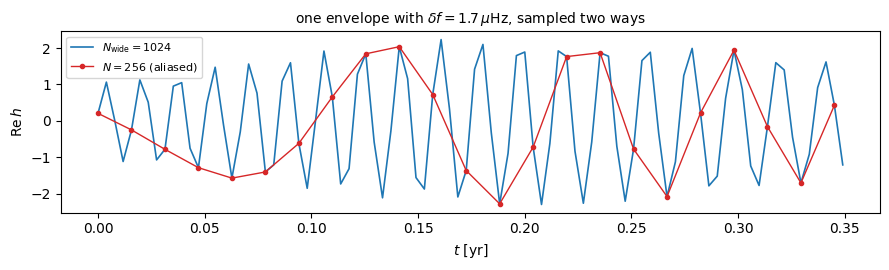

In [4]:
theta_check = sample_prior(2000)
snr_wide = signal_wide(theta_check).pow(2).sum(-1).sqrt()
snr_p1 = signal(theta_check).pow(2).sum(-1).sqrt()
print(f"SNR range {snr_wide.min():.0f} .. {snr_wide.max():.0f} "
      f"(median {snr_wide.median():.0f}); wide / Part 1 SNR = {(snr_wide / snr_p1).mean():.4f}")

theta_fast = torch.tensor([[4.0, 1.7e-6, 6e-17, 0.0, 0.5]], device=device)
mask_w, mask_p1 = (t_wide / YEAR).cpu() < 0.35, (t / YEAR).cpu() < 0.35
plt.figure(figsize=(9, 2.8))
plt.plot((t_wide / YEAR).cpu()[mask_w], envelope(theta_fast, t_wide)[0].real.cpu()[mask_w],
         color="C0", lw=1.2, label=rf"$N_{{\rm wide}} = {N_WIDE}$")
plt.plot((t / YEAR).cpu()[mask_p1], envelope(theta_fast, t)[0].real.cpu()[mask_p1],
         "o-", color="C3", ms=3, lw=1.0, label=f"$N = {N}$ (aliased)")
plt.xlabel("$t$ [yr]"); plt.ylabel(r"Re$\,h$")
plt.title(r"one envelope with $\delta f = 1.7\,\mu$Hz, sampled two ways", fontsize=10)
plt.legend(fontsize=8); plt.tight_layout()

Sampled at Part 1's rate, a source near the edge of the widened prior aliases to a slow beat and becomes
indistinguishable from a source at a quite different frequency. That is the reason
$N_{\rm wide} > N$: without it the likelihood itself would be wrong.

Now fix an observation: Part 1's source, moved to $\delta f = 1.3375\,\mu$Hz, somewhere in the
middle of the widened prior.

In [5]:
theta_true = torch.tensor([[4.2, 1.3375e-6, 6e-17, 2.0, 0.6]], device=device)
torch.manual_seed(11)
d_obs = simulate_wide(theta_true)
print(f"observation: SNR {signal_wide(theta_true).pow(2).sum().sqrt():.1f}, "
      f"{d_obs.shape[1]} real data features")

observation: SNR 33.1, 2048 real data features


---
# 2. NPE with the wide prior

<!-- *(~5 min)* -->

The obvious response is to retrain. Same flow as Part 1, same number of simulations, trained for 64 epochs. The only difference is that the context is now $2N_{\rm wide} = 2048$ numbers rather than 512, which by itself triples the parameter count.

In [6]:
def create_base_transform(param_dim, context_dim, hidden_dim=128, num_transform_blocks=2):
    """One masked affine autoregressive step (Part 1, section 3)."""
    return transforms.MaskedAffineAutoregressiveTransform(
        param_dim, hidden_features=hidden_dim, context_features=context_dim,
        num_blocks=num_transform_blocks, activation=nn.ELU(), use_batch_norm=False)


def create_linear_transform(param_dim):
    """Permutation (log|det J| = 0) followed by a learned LU-parametrized linear map."""
    return transforms.CompositeTransform([
        transforms.RandomPermutation(features=param_dim),
        transforms.LULinear(param_dim, identity_init=True)])


def create_flow(num_flow_steps, param_dim, context_dim, **base_transform_kwargs):
    """A standard normal base distribution followed by num_flow_steps (linear + base) steps.

    Parameters
    ----------
    num_flow_steps : int
        Number of (linear + base) steps; one further linear map is appended.
    param_dim : int
        Dimension D of theta.
    context_dim : int
        Dimension of the conditioning data d.
    **base_transform_kwargs
        Forwarded to `create_base_transform` (hidden_dim, num_transform_blocks).

    Returns
    -------
    flows.Flow
        Conditional flow supporting `.log_prob(theta, d)` and `.sample(n, d)`.
    """
    transform = transforms.CompositeTransform(
        [transforms.CompositeTransform([
            create_linear_transform(param_dim),
            create_base_transform(param_dim, context_dim, **base_transform_kwargs)])
         for _ in range(num_flow_steps)]
        + [create_linear_transform(param_dim)])
    return flows.Flow(transform, distributions.StandardNormal(shape=[param_dim]))


class GBDataset(Dataset):
    """Noise-free signals and parameters; noise is drawn afresh on every access."""

    def __init__(self, theta, signals):
        self.theta, self.signals = theta, signals

    def __len__(self):
        return len(self.theta)

    def __getitem__(self, idx):
        s = self.signals[idx]
        return s + NOISE_STD * torch.randn_like(s), self.theta[idx]


def make_loader(dataset, batch_size=512, shuffle=True):
    """DataLoader that passes a whole batch of indices to __getitem__ at once."""
    order = RandomSampler(dataset) if shuffle else range(len(dataset))
    return DataLoader(dataset, batch_size=None,
                      sampler=BatchSampler(order, batch_size=batch_size, drop_last=shuffle))


def train(flow, train_loader, val_loader, epochs, lr=1e-3, report_every=8):
    """Fit the flow by minibatch NLL, skipping updates whose gradient norm is not finite."""
    optimizer = torch.optim.Adam(flow.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history = {"train": [], "val": []}
    t0 = time.time()
    for epoch in range(epochs):
        flow.train()
        total, n = 0.0, 0
        for d, theta in train_loader:
            loss = -flow.log_prob(theta, d).mean()
            optimizer.zero_grad()
            loss.backward()
            if torch.isfinite(torch.nn.utils.clip_grad_norm_(flow.parameters(), 5.0)):
                optimizer.step()
                total += loss.item() * len(d)
                n += len(d)
        history["train"].append(total / max(n, 1))
        flow.eval()
        with torch.no_grad():
            history["val"].append(sum(-flow.log_prob(th, d).sum().item()
                                      for d, th in val_loader) / len(val_loader.dataset))
        scheduler.step()
        if epoch == epochs - 1 or (report_every and epoch % report_every == 0):
            print(f"epoch {epoch:4d}   train {history['train'][-1]:8.3f}"
                  f"   val {history['val'][-1]:8.3f}   ({time.time() - t0:.0f} s)")
    return history

In [8]:
TRAIN_LIVE = False                # False -> load the stored network; training is about
                                 # 10 min on CPU, 3 min on a T4
CHECKPOINT = "checkpoints/part2a_wide_flow.pt"
N_EPOCHS = 64                    # this notebook's wide-network budget; Part 1's checkpoint
                                 # had 128, which section 2 accounts for

flow_wide = create_flow(num_flow_steps=5, param_dim=5, context_dim=2 * N_WIDE,
                        hidden_dim=128).to(device)
print(f"{sum(p.numel() for p in flow_wide.parameters()):,} trainable parameters "
      f"(Part 1: 1,325,670)")

if TRAIN_LIVE:
    theta_tr = sample_prior(100_000)
    theta_va = sample_prior(10_000)
    sig_tr = torch.cat([signal_wide(theta_tr[i:i + 5000]) for i in range(0, 100_000, 5000)])
    sig_va = torch.cat([signal_wide(theta_va[i:i + 5000]) for i in range(0, 10_000, 5000)])
    t0 = time.time()
    history = train(flow_wide,
                    make_loader(GBDataset((theta_tr - THETA_MEAN) / THETA_STD, sig_tr)),
                    make_loader(GBDataset((theta_va - THETA_MEAN) / THETA_STD, sig_va),
                                shuffle=False),
                    N_EPOCHS)
    os.makedirs("checkpoints", exist_ok=True)
    torch.save({"state_dict": flow_wide.state_dict(), "history": history, "n_epochs": N_EPOCHS,
                "device": device, "seconds": time.time() - t0}, CHECKPOINT)
else:
    ckpt = torch.load(CHECKPOINT, map_location=device, weights_only=False)
    flow_wide.load_state_dict(ckpt["state_dict"])
    history = ckpt["history"]
    print(f"loaded {CHECKPOINT}: {ckpt['n_epochs']} epochs on {ckpt['device']}, "
          f"{ckpt['seconds'] / 60:.0f} min")
flow_wide.eval();

4,274,790 trainable parameters (Part 1: 1,325,670)
loaded checkpoints/part2a_wide_flow.pt: 64 epochs on cpu, 10 min


The loss is a negative log density in standardized parameters, so comparing it with Part 1's takes
one step of bookkeeping. The two networks describe the same physical posterior; the wide one merely
expresses it relative to a prior $W$ times broader in $\delta f$, and that is worth exactly
$\log W$ nats. A wide network that had lost *nothing* to the widening would therefore land
$\log 20 = 3.0$ nats below Part 1's final validation loss.

The step also assumes the average posterior entropy is the same under both priors, which holds here
to about $0.01$ nats: the posterior spans some $0.5\%$ of even the narrow $\delta f$ prior, so
truncation at the prior edges is negligible in both cases.

Part 1, its own prior             -5.090
same posterior, wide prior        -8.086   (Part 1 - log W)
naive wide network                 1.060
shortfall                          9.145 nats  ->  9369x too little density at the truth

wide network gained 0.061 nats over its last 8 epochs


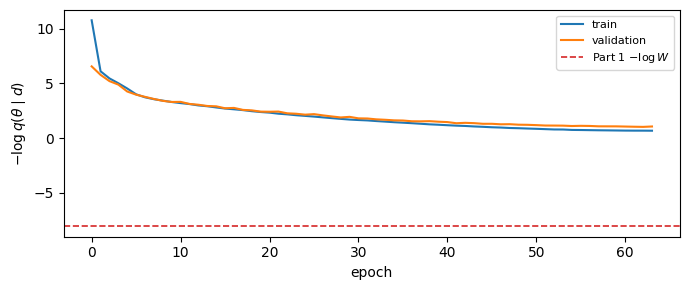

In [9]:
# If you are not running from a clone of the repository, fetch the stored networks first:
# !mkdir -p checkpoints && wget -q -P checkpoints \
#     https://github.com/stephengreen/LISAAI-Hackathon-ESTEC/raw/main/checkpoints/part1_flow_v2.pt \
#     https://github.com/stephengreen/LISAAI-Hackathon-ESTEC/raw/main/checkpoints/part2a_wide_flow.pt \
#     https://github.com/stephengreen/LISAAI-Hackathon-ESTEC/raw/main/checkpoints/part2a_confusion_flow.pt
part1_ckpt = torch.load("checkpoints/part1_flow_v2.pt", map_location=device, weights_only=False)
part1_val = part1_ckpt["history"]["val"][-1]
target = part1_val - np.log(W_WIDE)

plt.figure(figsize=(7, 3))
plt.plot(history["train"], label="train")
plt.plot(history["val"], label="validation")
plt.axhline(target, color="C3", ls="--", lw=1.2, label=r"Part 1 $- \log W$")
plt.xlabel("epoch"); plt.ylabel(r"$-\log q(\theta \mid d)$")
plt.legend(fontsize=8); plt.tight_layout()

gap = history["val"][-1] - target
tail = history["val"][-9] - history["val"][-1]
print(f"Part 1, its own prior           {part1_val:8.3f}")
print(f"same posterior, wide prior      {target:8.3f}   (Part 1 - log W)")
print(f"naive wide network              {history['val'][-1]:8.3f}")
print(f"shortfall                       {gap:8.3f} nats  ->  {np.exp(gap):.0f}x too little "
      f"density at the truth")
print(f"\nwide network gained {tail:.3f} nats over its last 8 epochs")

The Part 1 checkpoint had twice the epoch budget, so it is worth asking whether the gap is simply
undertraining. It is not: the wide network gained a few hundredths of a nat over its last eight
epochs, against a shortfall of nine. Doubling its budget would not close a gap of that size, and
the reason is not optimization. The same $10^5$ simulations must now cover a box twenty times larger
in the one direction the posterior is sharpest.

### The exact answer

The likelihood is a Gaussian we can evaluate, so Part 1's reference sampler gives an exact
posterior to compare against, run here on the wide problem. It is seeded at $\theta_{\rm true}$
because this is a reference computation rather than a search, and section 4 establishes separately
that no other region of the prior contributes.

In [10]:
# Part 1's reference sampler, verbatim. gb_wide.py carries the same function with self-tests.
def reference_posterior(log_post, theta0, mean, sd, n_chains=256, n_steps=3000, thin=4, seed=0,
                        n_pilot=3, pilot_steps=300, init=1e-4):
    """Preconditioned random-walk Metropolis in standardized coordinates.

    In physical units the five parameters span seventeen orders of magnitude and one proposal
    covariance cannot serve them all. The ensemble starts clustered on theta0 and the proposal
    covariance is re-estimated n_pilot times from the ensemble, growing to fit the posterior;
    acceptance should settle around 0.2-0.4.

    Parameters
    ----------
    log_post : callable
        Maps physical parameters (B, 5) to log posterior densities (B,).
    theta0 : torch.Tensor
        Starting point in physical units, shape (5,).
    mean, sd : torch.Tensor
        Standardization constants, shape (5,).
    n_chains : int, optional
        Chains run in parallel.
    n_steps : int, optional
        Production steps per chain.
    thin : int, optional
        Keep every thin-th production step.
    seed : int, optional
        Seed for the chain randomness.
    n_pilot : int, optional
        Proposal-tuning stages run before production.
    pilot_steps : int, optional
        Steps per pilot stage.
    init : float, optional
        Initial ensemble spread and proposal scale, in standardized units.

    Returns
    -------
    samples : torch.Tensor
        Physical-unit samples, shape (n_chains * n_steps // thin, 5).
    accs : list of float
        Mean acceptance per stage, pilots first and production last.
    """
    torch.manual_seed(seed)
    u = (theta0 - mean) / sd + init * torch.randn(n_chains, 5, device=device)
    lp = log_post(u * sd + mean)
    L = init * torch.eye(5, device=device)
    accs, keep = [], []
    for stage, n_stage in enumerate([pilot_steps] * n_pilot + [n_steps]):
        n_acc = 0.0
        for i in range(n_stage):
            v = u + torch.randn(n_chains, 5, device=device) @ L.T
            lq = log_post(v * sd + mean)
            a = torch.rand(n_chains, device=device).log() < (lq - lp)
            u, lp = torch.where(a[:, None], v, u), torch.where(a, lq, lp)
            n_acc += a.float().mean().item()
            if stage == n_pilot and i % thin == 0:
                keep.append(u.clone())
        accs.append(n_acc / n_stage)
        if stage < n_pilot:                 # re-estimate the proposal from the ensemble
            cov = torch.cov(u.T)
            L = torch.linalg.cholesky(cov + 1e-8 * torch.diag(cov.diag())) * 2.38 / np.sqrt(5)
    return torch.cat(keep) * sd + mean, accs


def log_posterior(theta, d):
    """Exact log posterior on the wide data: likelihood inside the prior box, -1e30 outside."""
    inside = ((theta > PRIOR_LOW) & (theta < PRIOR_HIGH)).all(-1)
    return torch.where(inside, log_likelihood_wide(theta, d), torch.full_like(theta[:, 0], -1e30))


t0 = time.time()
exact, accept = reference_posterior(lambda th: log_posterior(th, d_obs),
                                    theta_true, THETA_MEAN, THETA_STD)
print(f"{len(exact):,} reference samples in {time.time() - t0:.0f} s "
      f"(acceptance {accept[-1]:.2f}, pilots {[f'{a:.2f}' for a in accept[:-1]]})")

with torch.no_grad():
    naive = flow_wide.sample(50_000, d_obs)[0] * THETA_STD + THETA_MEAN

names = ["A", "df", "fdot", "phi0", "cos_i"]
# THETA_STD is the standard deviation of the (uniform) prior, so dividing by it says what
# fraction of the prior each marginal still occupies -- how much was actually learned.
print(f"\n{'':>7} {'exact sd':>12} {'naive sd':>12} {'ratio':>8} "
      f"{'exact/prior':>12} {'naive/prior':>12}")
for i, name in enumerate(names):
    print(f"{name:>7} {exact[:, i].std() * PLOT_SCALE[i]:12.4g} "
          f"{naive[:, i].std() * PLOT_SCALE[i]:12.4g} "
          f"{naive[:, i].std() / exact[:, i].std():8.1f} "
          f"{float(exact[:, i].std() / THETA_STD[i]):11.2%} "
          f"{float(naive[:, i].std() / THETA_STD[i]):11.1%}")

192,000 reference samples in 8 s (acceptance 0.31, pilots ['0.55', '0.68', '0.55'])

            exact sd     naive sd    ratio  exact/prior  naive/prior
      A       0.6002        1.238      2.1      37.13%       76.6%
     df    0.0005264      0.03235     61.5       0.05%        2.8%
   fdot       0.8182        2.272      2.8      40.49%      112.4%
   phi0      0.09299        1.212     13.0       5.13%       66.8%
  cos_i       0.1414       0.5645      4.0      24.49%       97.8%


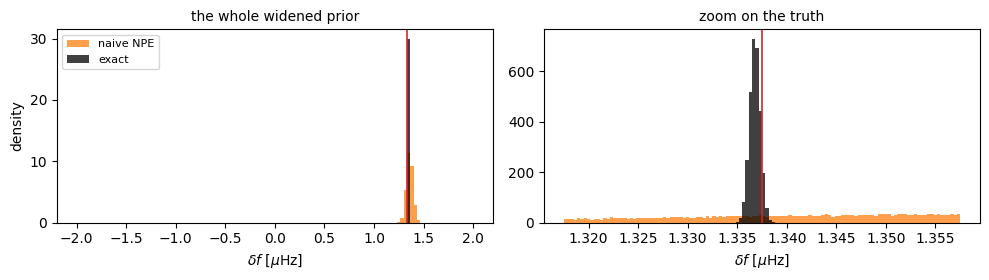

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 2.9))
for ax, (lo, hi, title) in zip(axes, [
        (-W_WIDE * DF_P1 * 1e6, W_WIDE * DF_P1 * 1e6, "the whole widened prior"),
        (1.3375 - 0.02, 1.3375 + 0.02, "zoom on the truth")]):
    ax.hist((naive[:, 1] * 1e6).cpu(), bins=120, range=(lo, hi), density=True,
            color="C1", alpha=0.75, label="naive NPE")
    ax.hist((exact[:, 1] * 1e6).cpu(), bins=120, range=(lo, hi), density=True,
            color="k", alpha=0.75, label="exact")
    ax.axvline(1.3375, color="C3", lw=1.2)
    ax.set_xlabel(r"$\delta f\ [\mu{\rm Hz}]$"); ax.set_title(title, fontsize=10)
axes[0].set_ylabel("density"); axes[0].legend(fontsize=8)
plt.tight_layout()

The naive posterior is in the right place and way too broad: by a factor of sixty in $\delta f$,
and by factors of between two and thirteen in the others. 

<!-- Read the last two columns before deciding which parameters that
ruins. $\delta f$ is the one parameter with four years of baseline behind it, so its information
carries a factor of $(\mathrm{SNR} \times T_{\rm obs})^2$, and even sixty times degraded it still
occupies a few per cent of its prior and remains the best-measured quantity in the problem. The
other four have no such enhancement, and they come back between two-thirds and the full width of
the prior. For $\dot f$ and $\cos\iota$ that is indistinguishable from having learned nothing;
$\dot f$ is in fact returned *wider* than the prior it was trained on, a flow being under no
obligation to respect the box. Conditioning is worth doing for those four, not for $\delta f$. This is not a bug, and more epochs will
not rescue it. The network is being asked to resolve a feature $10^{-3}$ of the prior wide from
$10^5$ examples spread across the whole box, reading 2048 raw numbers with no embedding network to
help. This is the sample-starvation pathology from Christoph Weniger's session on Monday: an
amortized network trained on 32,768 wide-prior simulations, of which only a couple of dozen
landed near the posterior, came out about a factor of ten too wide in every direction. -->

<!-- Nothing in the rest of this notebook is trained on the wide prior. -->

---
# 3. Heterodyning: back to Part 1's problem

<!-- *(~4 min)* -->

Binary neutron star signals are too long to hand a network raw. DINGO-BNS makes them tractable by
heterodyning the data with the model phase and discarding the bandwidth that step frees up. A
constant-frequency binary is the degenerate case of that construction, so this section is DINGO-BNS
in miniature.

Suppose someone hands us a guess $\widehat{\delta f}$. Multiplying the data by
$e^{-2\pi i \widehat{\delta f} t}$ shifts every frequency down by $\widehat{\delta f}$, so a source
at $\delta f$ lands at the *residual* frequency $\delta f - \widehat{\delta f}$, and the bandwidth
we paid $R$ samples for is empty. Select the band we still need and throw the rest away:
$$
\bar d \;=\; \frac{1}{\sqrt{R}}\;
{\rm DFT}_N^{-1}\Bigl[\;\Pi_N \;{\rm DFT}_{N_{\rm wide}}
\bigl[\, d(t)\, e^{-2\pi i \widehat{\delta f} t} \,\bigr]\;\Bigr],
$$
where $\Pi_N$ keeps the central $N$ frequency bins. The $1/\sqrt{R}$ restores unit noise variance,
since only $N$ of the $N_{\rm wide}$ noise bins survive. (A block average of $R$ samples is one line
shorter but is a sinc filter with sidelobes only $13$ dB down; exercise (a) measures the difference.)

Three nested frequency scales are in play:

- $\pm 2\,\mu$Hz — the widened prior: where the true $\delta f$ may lie, twenty times Part 1's.
- $\pm 1.01\,\mu$Hz — the band that survives: keeping $N = 256$ bins of the wide record leaves
  frequencies up to Part 1's Nyquist, $1/2\Delta t \approx 1.01\,\mu$Hz. Fixed by the network's
  input size, not chosen.
- $\pm 0.1\,\mu$Hz — Part 1's prior on $\delta f$: the *residual* $\delta f - \widehat{\delta f}$
  must land inside it, and section 4 spaces the guesses so it always does.

The middle scale is bandwidth, not prior: Part 1's grid always held $\pm 1\,\mu$Hz of spectrum
even though its prior confined $\delta f$ to a tenth of that. Demodulation moves the source from
anywhere in the first scale to inside the third; the second is simply what the 256 retained
samples can represent. The output is Part 1's data, Part 1's prior, **Part 1's problem**.

Brick-wall truncation costs about $2\%$ in signal fidelity, since the record is not periodic.
Conditioning only builds a *proposal*, and section 4 evaluates the exact likelihood on the original
wide data, so an approximation here costs efficiency, never correctness.

In [12]:
def condition(d, df_hat):
    """Demodulate by df_hat, keep the central N frequency bins, rescale.

    Parameters
    ----------
    d : torch.Tensor
        Wide-grid features [Re, Im], shape (..., 2 N_WIDE).
    df_hat : torch.Tensor or float
        Frequency guess to demodulate by [Hz].

    Returns
    -------
    torch.Tensor
        Part 1-format features [Re, Im], shape (..., 2 N), with unit noise variance.
    """
    z = torch.complex(d[..., :N_WIDE], d[..., N_WIDE:])
    z = z * torch.exp(-2j * np.pi * df_hat * t_wide)
    spectrum = torch.fft.fftshift(torch.fft.fft(z), dim=-1)
    lo = (N_WIDE - N) // 2
    z = torch.fft.ifft(torch.fft.ifftshift(spectrum[..., lo:lo + N], dim=-1)) / np.sqrt(R)
    return torch.cat([z.real, z.imag], dim=-1)


# One guess, handed to us for now; section 4 generates them systematically.
df_hat = torch.tensor(1.35e-6, device=device)
BAND = 1 / (2 * DT)                    # half-width of the retained band = Part 1's Nyquist frequency
print(f"guess {float(df_hat) * 1e6:.3f} uHz  ->  residual "
      f"{float(theta_true[0, 1] - df_hat) * 1e9:+.1f} nHz")
print(f"widened prior +/- {W_WIDE * DF_P1 * 1e6:.2f} uHz   band kept +/- {BAND * 1e6:.2f} uHz"
      f"   network prior +/- {DF_P1 * 1e6:.2f} uHz")

guess 1.350 uHz  ->  residual -12.5 nHz
widened prior +/- 2.00 uHz   band kept +/- 1.01 uHz   network prior +/- 0.10 uHz


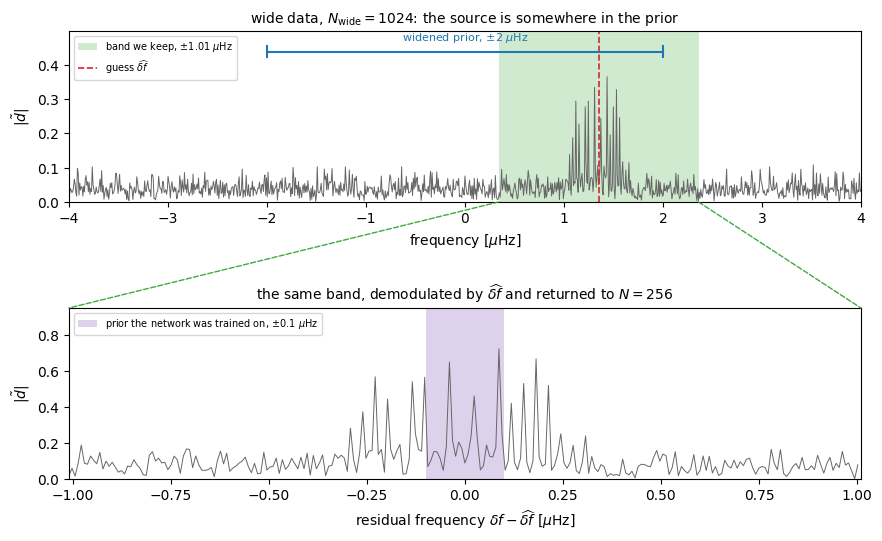

In [13]:
C_PRIOR, C_BAND, C_NET, C_HAT = "C0", "C2", "C4", "C3"

fig, axes = plt.subplots(2, 1, figsize=(9, 5.6))
fig.subplots_adjust(hspace=0.62, left=0.10, right=0.98, top=0.90, bottom=0.10)

# --- top: the wide record on the wide grid ------------------------------------------------
f_wide = np.fft.fftshift(np.fft.fftfreq(N_WIDE, d=DT / R)) * 1e6
z_wide = torch.complex(d_obs[0, :N_WIDE], d_obs[0, N_WIDE:]).cpu().numpy()
axes[0].plot(f_wide, np.abs(np.fft.fftshift(np.fft.fft(z_wide))) / N_WIDE, lw=0.7, color="0.4")
lo_b, hi_b = (float(df_hat) - BAND) * 1e6, (float(df_hat) + BAND) * 1e6
axes[0].axvspan(lo_b, hi_b, color=C_BAND, alpha=0.22, lw=0,
                label=r"band we keep, $\pm 1.01\ \mu$Hz")
axes[0].axvline(float(df_hat) * 1e6, color=C_HAT, ls="--", lw=1.2,
                label=r"guess $\widehat{\delta f}$")
axes[0].set_xlim(-4, 4)
axes[0].set_ylim(0, axes[0].get_ylim()[1] * 1.30)

# the widened prior as a bracket, so no two shaded regions ever overlap
tr = axes[0].get_xaxis_transform()
xp = W_WIDE * DF_P1 * 1e6
axes[0].plot([-xp, xp], [0.88, 0.88], color=C_PRIOR, lw=1.5, transform=tr)
for xe in (-xp, xp):
    axes[0].plot([xe, xe], [0.85, 0.91], color=C_PRIOR, lw=1.5, transform=tr)
axes[0].text(0, 0.92, r"widened prior, $\pm 2\ \mu$Hz", color=C_PRIOR, fontsize=8,
             ha="center", va="bottom", transform=tr)
axes[0].set_title(r"wide data, $N_{\rm wide} = 1024$: the source is somewhere in the prior",
                  fontsize=10)
axes[0].set_xlabel(r"frequency $[\mu{\rm Hz}]$")
axes[0].legend(fontsize=7, loc="upper left")

# --- bottom: what that band contains, on Part 1's grid -------------------------------------
d_cond = condition(d_obs, df_hat)
f_p1 = np.fft.fftshift(np.fft.fftfreq(N, d=DT)) * 1e6
z_p1 = torch.complex(d_cond[0, :N], d_cond[0, N:]).cpu().numpy()
axes[1].plot(f_p1, np.abs(np.fft.fftshift(np.fft.fft(z_p1))) / N, lw=0.7, color="0.4")
axes[1].axvspan(-DF_P1 * 1e6, DF_P1 * 1e6, color=C_NET, alpha=0.30, lw=0,
                label=r"prior the network was trained on, $\pm 0.1\ \mu$Hz")
axes[1].set_xlim(-BAND * 1e6, BAND * 1e6)
axes[1].set_ylim(0, axes[1].get_ylim()[1] * 1.25)
axes[1].set_title(r"the same band, demodulated by $\widehat{\delta f}$ and returned to $N = 256$",
                  fontsize=10)
axes[1].set_xlabel(r"residual frequency $\delta f - \widehat{\delta f}\ [\mu{\rm Hz}]$")
axes[1].legend(fontsize=7, loc="upper left")

for ax in axes:
    ax.set_ylabel(r"$|\tilde d|$")

# --- the zoom: kept-band edges above, panel corners below ----------------------------------
for x_top, x_frac in [(lo_b, 0.0), (hi_b, 1.0)]:
    fig.add_artist(ConnectionPatch(
        xyA=(x_top, 0.0), coordsA=axes[0].get_xaxis_transform(),
        xyB=(x_frac, 1.0), coordsB=axes[1].transAxes,
        color=C_BAND, lw=1.0, ls="--", alpha=0.9))

The band is ten times the prior for a reason the lower panel shows plainly: LISA's orbit spreads
even a fixed-frequency source into Doppler sidebands reaching $\pm 0.26\,\mu$Hz, so the residual
*carrier* sits inside $\pm 0.1\,\mu$Hz while the signal around it does not.

Two checks that the conditioned data is what Part 1's network expects: the signal survives the
round trip, and the noise comes out with unit variance.

In [14]:
theta_probe = sample_prior(500, P1_LOW, P1_HIGH)      # residuals across the network's own prior
theta_shift = theta_probe.clone()
theta_shift[:, 1] = theta_shift[:, 1] + df_hat       # the same sources, moved up to the guess
err = ((condition(signal_wide(theta_shift), df_hat) - signal(theta_probe))
       .pow(2).sum(-1).sqrt() / signal(theta_probe).pow(2).sum(-1).sqrt())
print(f"signal error after conditioning: median {err.median():.4f}, max {err.max():.4f}")
print("conditioned noise sd:            "
      f"{condition(torch.randn(2000, 2 * N_WIDE, device=device), df_hat).std():.4f}")

signal error after conditioning: median 0.0224, max 0.0377
conditioned noise sd:            0.9995


So point Part 1's network at the conditioned data. No training, no fine-tuning, no change of
architecture: the 512-feature input is the same 512-feature input.

In [15]:
flow_p1 = create_flow(num_flow_steps=5, param_dim=5, context_dim=2 * N, hidden_dim=128).to(device)
flow_p1.load_state_dict(part1_ckpt["state_dict"])
flow_p1.eval()

with torch.no_grad():
    single = flow_p1.sample(20_000, condition(d_obs, df_hat))[0] * P1_STD + P1_MEAN
single = single.clone()
single[:, 1] = single[:, 1] + df_hat      # undo the demodulation shift

print(f"{'':>7} {'exact sd':>12} {'naive sd':>12} {'conditioned':>12}")
for i, name in enumerate(names):
    print(f"{name:>7} {exact[:, i].std() * PLOT_SCALE[i]:12.4g}"
          f" {naive[:, i].std() * PLOT_SCALE[i]:12.4g}"
          f" {single[:, i].std() * PLOT_SCALE[i]:12.4g}")

            exact sd     naive sd  conditioned
      A       0.6002        1.238       0.7242
     df    0.0005264      0.03235    0.0006624
   fdot       0.8182        2.272       0.8571
   phi0      0.09299        1.212       0.1037
  cos_i       0.1414       0.5645         0.15


A network that has never seen a $1.3\,\mu$Hz source returns a posterior of the right width for one,
against factors of two to sixty for the model actually trained on this prior. It is not exact —
$\delta f$ comes out about a quarter too broad — but that is Part 1's flow, not the conditioning:
the same network is 20% too broad in $\delta f$ on its own problem (Part 1, §6.1). Section 4
measures the discrepancy and removes it.

---
# 4. The frequency scan

<!-- *(~5 min)* -->

Part 1 introduced importance sampling ([Dax et al. 2022](https://arxiv.org/abs/2210.05686)): draw
$\theta_i \sim q(\theta)$, weight each draw by
$w_i = \mathcal{L}(d \mid \theta_i)\,\pi(\theta_i) / q(\theta_i)$, and the weighted samples
represent the exact posterior however poor $q$ was, provided $q$ covers it. The sample efficiency
$\epsilon$ is defined there too and means the same thing here: $\epsilon n$ is the effective sample
size, and $\epsilon$ is a single-number verdict on the proposal.

What is new is that the mean weight also estimates the evidence
$Z = \int \mathcal{L}\pi \,{\rm d}\theta$, and that we now have a *family* of proposals rather than
one. Tile the widened prior, run the conditioning and the frozen network once per tile, and
importance sample each output against the exact likelihood restricted to that tile. The tiles have
equal prior volume, so the constant prior density cancels between them, the tile evidences are
directly comparable, and
$$
P(\text{tile } k \mid d) \;\propto\; Z_k .
$$
Drawing tiles in that proportion and resampling within each by weight stitches the pieces into the
global posterior.

The proxies are spaced by $10^{-7}$ Hz, *half* the width of the prior the network was trained on,
so the residual $\delta f$ it is handed never exceeds half of what it has seen. Spacing them by the
full prior width costs half as much and works almost everywhere, but a source landing near a tile
boundary is then evaluated at the very edge of the network's training range and comes back about
$20\%$ too narrow in $\delta f$, a bias that does not go away with more samples. Halving the spacing
removes it, and improves $\epsilon$ elsewhere too.

In [16]:
# Proxies spaced by DF_P1, half the width of the prior the network was trained on. Each owns a
# tile of half-width DF_P1 / 2, and the 2W tiles exactly partition the widened prior.
TILE_HALF = DF_P1 / 2
DF_HAT = -W_WIDE * DF_P1 + (torch.arange(2 * W_WIDE, device=device) + 0.5) * DF_P1
K_TRUE = int((DF_HAT - theta_true[0, 1]).abs().argmin())
assert abs(float(DF_HAT[K_TRUE] - df_hat)) < 1e-11   # section 3's guess is tile K_TRUE's proxy
print(f"{len(DF_HAT)} tiles of width {2 * TILE_HALF * 1e9:.0f} nHz; the truth lies in tile "
      f"{K_TRUE}, proxy {DF_HAT[K_TRUE] * 1e6:.3f} uHz, residual "
      f"{(theta_true[0, 1] - DF_HAT[K_TRUE]) * 1e9:+.1f} nHz")

40 tiles of width 100 nHz; the truth lies in tile 33, proxy 1.350 uHz, residual -12.5 nHz


In [17]:
def tile_posterior(d, k, n):
    """Frozen Part 1 network on tile k, importance-weighted against the exact likelihood.

    Parameters
    ----------
    d : torch.Tensor
        Wide-grid observation, shape (2 N_WIDE,).
    k : int
        Tile index into DF_HAT.
    n : int
        Number of posterior draws.

    Returns
    -------
    theta : torch.Tensor
        Draws in the wide parameter space (absolute delta f), shape (n, 5).
    log_w : torch.Tensor
        Log importance weights against the tile-restricted prior and exact likelihood;
        -inf for draws outside the tile, shape (n,).
    """
    df_hat = DF_HAT[k]
    with torch.no_grad():
        theta, log_q = flow_p1.sample_and_log_prob(n, condition(d, df_hat))
    theta = (theta[0] * P1_STD + P1_MEAN).clone()
    theta[:, 1] = theta[:, 1] + df_hat                       # back to absolute frequency
    log_q = log_q[0] - torch.log(P1_STD).sum()               # density in physical units

    low, high = PRIOR_LOW.clone(), PRIOR_HIGH.clone()        # the prior restricted to this tile
    low[1], high[1] = df_hat - TILE_HALF, df_hat + TILE_HALF
    inside = ((theta > low) & (theta < high)).all(-1)
    log_prior = -torch.log(high - low).sum()
    return theta, torch.where(inside, log_likelihood_wide(theta, d) + log_prior - log_q,
                              torch.full_like(log_q, -torch.inf))


def evidence_and_efficiency(log_w):
    """Evidence and sample efficiency from log weights, computed stably.

    Parameters
    ----------
    log_w : torch.Tensor
        Log importance weights, shape (n,).

    Returns
    -------
    log_Z : float
        log mean(w), the tile evidence.
    eps : float
        (sum w)^2 / (n sum w^2), in [0, 1]; 0.0 if no weight is finite.
    """
    n = len(log_w)
    lse = torch.logsumexp(log_w, 0)
    if not torch.isfinite(lse):                              # nothing landed inside the tile
        return -np.inf, 0.0
    log_eps = 2 * lse - np.log(n) - torch.logsumexp(2 * log_w, 0)
    return (lse - np.log(n)).item(), log_eps.exp().item()

In [18]:
N_SCAN = 4000                     # draws per tile in the scan pass

t0 = time.time()
log_Z = np.zeros(len(DF_HAT))
eps = np.zeros(len(DF_HAT))
for k in range(len(DF_HAT)):
    log_Z[k], eps[k] = evidence_and_efficiency(tile_posterior(d_obs, k, N_SCAN)[1])
t_scan = time.time() - t0

k_best = int(log_Z.argmax())
ranked = np.sort(log_Z[np.isfinite(log_Z)])
print(f"{len(DF_HAT)} tiles in {t_scan:.1f} s ({t_scan / len(DF_HAT) * 1e3:.0f} ms per tile); "
      f"{int((~np.isfinite(log_Z)).sum())} tile(s) had no draw land inside")
print(f"best tile {k_best} (true tile {K_TRUE}), proxy {DF_HAT[k_best] * 1e6:.3f} uHz; "
      f"log Z ahead of the runner-up by {ranked[-1] - ranked[-2]:.0f} nats")

40 tiles in 7.5 s (187 ms per tile); 1 tile(s) had no draw land inside
best tile 33 (true tile 33), proxy 1.350 uHz; log Z ahead of the runner-up by 239 nats


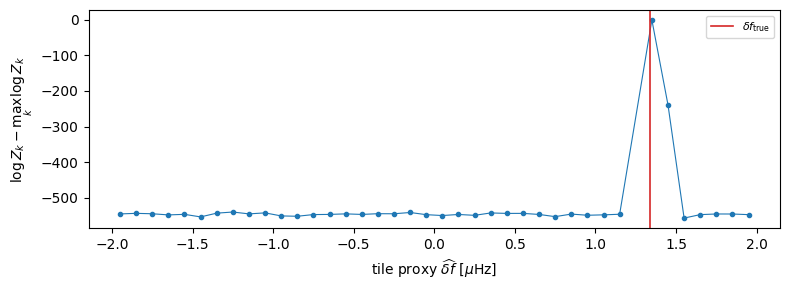

In [19]:
# Tiles that received no in-tile draw have log Z = -inf and are simply not plotted.
ok = np.isfinite(log_Z)
plt.figure(figsize=(8, 3))
plt.plot(DF_HAT.cpu()[ok] * 1e6, (log_Z - log_Z.max())[ok], "o-", ms=3, lw=0.8)
plt.axvline(float(theta_true[0, 1]) * 1e6, color="C3", lw=1.2, label=r"$\delta f_{\rm true}$")
plt.xlabel(r"tile proxy $\widehat{\delta f}\ [\mu{\rm Hz}]$")
plt.ylabel(r"$\log Z_k - \max_k \log Z_k$")
plt.legend(fontsize=8); plt.tight_layout()

The evidence curve is a detection statistic, produced by evaluating a network that knows nothing
about where the source is, once per tile, and the same pass that located the source also produced
its posterior. Search and parameter estimation are not two stages here, they are one computation.

Seen in the frequency domain the whole scan is a single operation. Were the tile spacing chosen to
be a whole number of frequency bins, stepping from tile $k$ to tile $k+1$ would slide the retained
256-bin window along the frequency axis by that many bins: conditioning by heterodyne and selecting
a band are the same thing.

The second pass spends samples where the evidence says they matter.

In [20]:
N_FINAL = 200_000
weight = np.exp(log_Z - log_Z.max())
weight = weight / weight.sum()

t0 = time.time()
draws, eps_final = [], np.zeros(len(DF_HAT))
for k in np.nonzero(np.round(weight * N_FINAL) >= 1)[0]:
    theta_k, log_w_k = tile_posterior(d_obs, k, int(round(weight[k] * N_FINAL)))
    eps_final[k] = evidence_and_efficiency(log_w_k)[1]   # epsilon at the full draw count
    n_k = int(round(weight[k] * 40_000))
    draws.append(theta_k[torch.multinomial(torch.exp(log_w_k - log_w_k.max()), n_k,
                                           replacement=True)])
stitched = torch.cat(draws)
print(f"{len(stitched):,} stitched posterior samples from {len(draws)} tile(s) "
      f"in {time.time() - t0:.1f} s")

40,000 stitched posterior samples from 1 tile(s) in 9.5 s


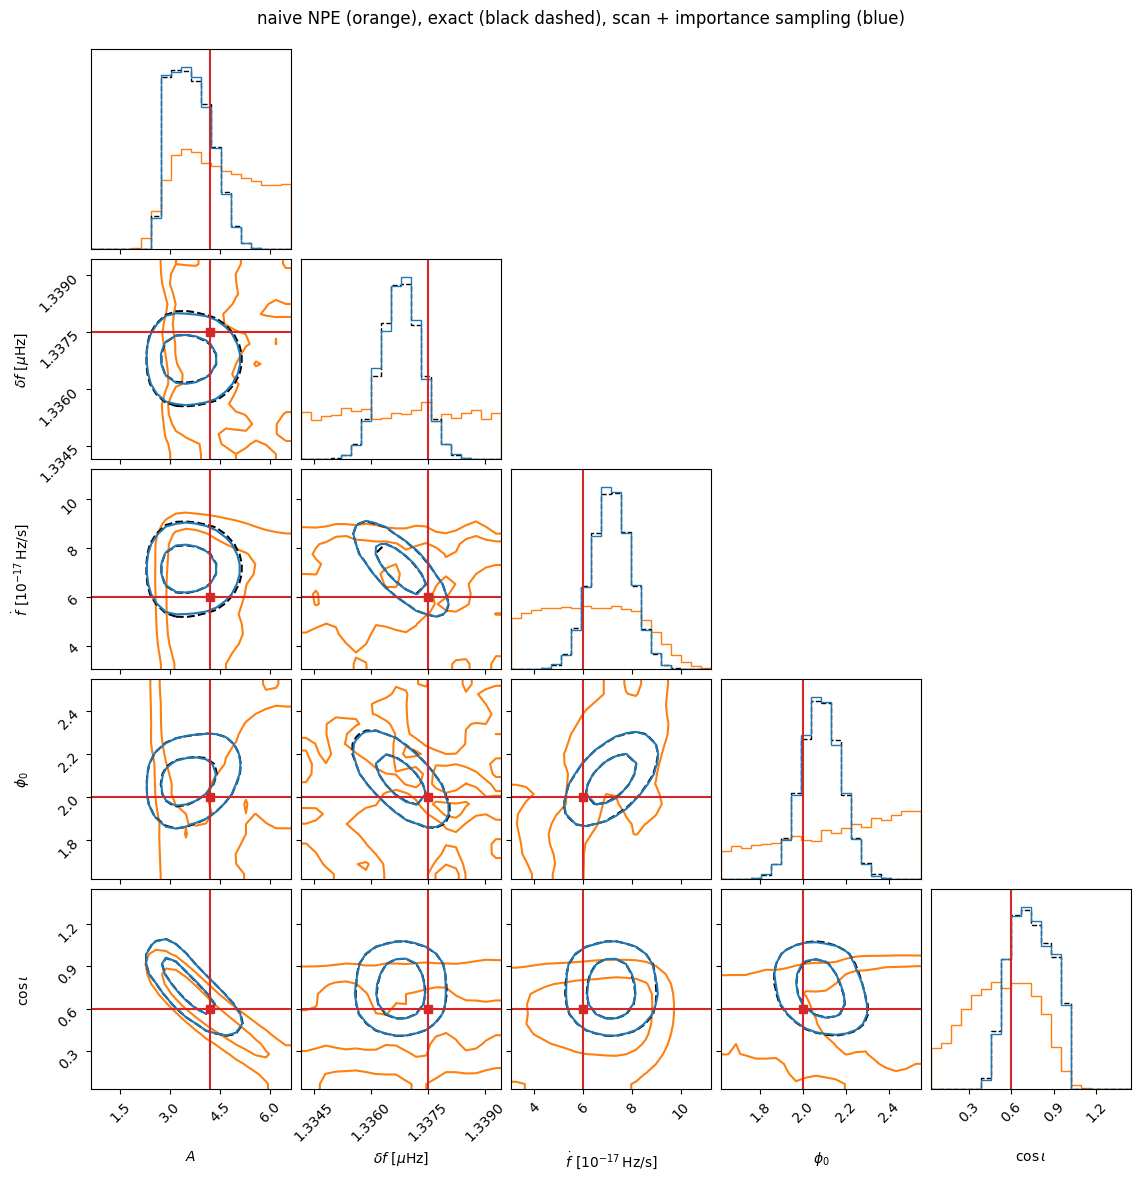

In [21]:
lim = [((exact[:, i].mean() - 5 * exact[:, i].std()) * PLOT_SCALE[i],
        (exact[:, i].mean() + 5 * exact[:, i].std()) * PLOT_SCALE[i]) for i in range(5)]
kw = dict(labels=LABELS, range=[(float(a), float(b)) for a, b in lim], levels=(0.5, 0.9),
          smooth=1.0, plot_datapoints=False, plot_density=False)
fig = corner.corner((naive * PLOT_SCALE).cpu().numpy(), color="C1",
                    hist_kwargs={"density": True}, **kw)
corner.corner((exact * PLOT_SCALE).cpu().numpy(), fig=fig, color="k",
              hist_kwargs={"density": True, "ls": "--"},
              contour_kwargs={"linestyles": "dashed"}, **kw)
corner.corner((stitched * PLOT_SCALE).cpu().numpy(), fig=fig, color="C0",
              hist_kwargs={"density": True},
              truths=(theta_true * PLOT_SCALE)[0].cpu().numpy(), truth_color="C3", **kw)
fig.suptitle("naive NPE (orange), exact (black dashed), scan + importance sampling (blue)",
             y=1.0);

The frame is five standard deviations of the exact posterior wide, which is why the naive model is
a nearly flat orange background: on the scale of the answer it carries almost no information. The
blue contours sit on the black dashed ones throughout.

The panels below zoom in on the two directions that matter most, and add the one curve the corner
plot leaves out: the raw conditioned flow, before any reweighting.

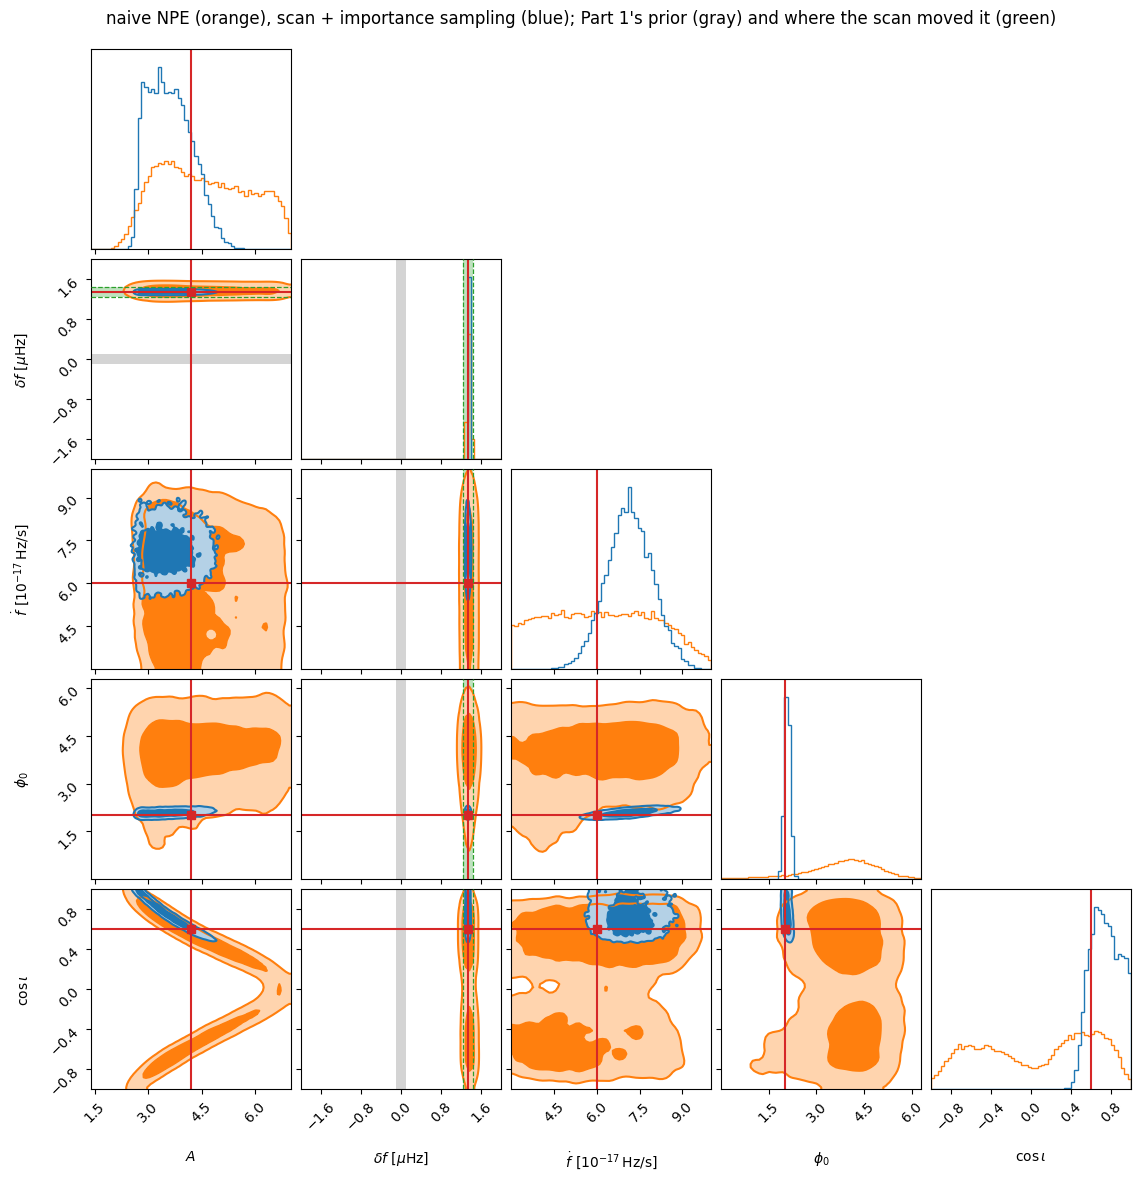

In [22]:
# Part 1 drew its posterior on the prior box, a needle in a haystack. Here is the same picture
# with a haystack twenty times longer in delta f.
prior_range = [(float(a), float(b)) for a, b in
               zip(PRIOR_LOW * PLOT_SCALE, PRIOR_HIGH * PLOT_SCALE)]
kw = dict(labels=LABELS, range=prior_range, levels=(0.5, 0.9), plot_datapoints=False,
          plot_density=False, fill_contours=True)
# The stitched posterior covers 0.016% of the delta f axis, so it needs far finer bins than the
# naive one: at 60 bins it lands inside a single bin and no contour closes around it.
fig = corner.corner((naive * PLOT_SCALE).cpu().numpy(), color="C1", bins=60, smooth=1.5,
                    hist_kwargs={"density": True}, **kw)
corner.corner((stitched * PLOT_SCALE).cpu().numpy(), fig=fig, color="C0", bins=500, smooth=4.0,
              hist_bin_factor=60 / 500, hist_kwargs={"density": True},
              truths=(theta_true * PLOT_SCALE)[0].cpu().numpy(), truth_color="C3", **kw)

# Two bands of identical width in the delta f panels: the prior the network was trained on, and
# where the winning proxy moved that same window to. The heterodyne is the move.
ax_grid = np.array(fig.axes).reshape(5, 5)
band = float(DF_P1 * PLOT_SCALE[1])
centre = float(DF_HAT[k_best] * PLOT_SCALE[1])
trained = dict(color="0.45", alpha=0.30, lw=0, zorder=-5)
moved = dict(color="C2", alpha=0.30, lw=0, zorder=-5)
edge = dict(color="C2", lw=0.9, ls="--", zorder=10)
for i in range(1, 5):
    ax_grid[i, 1].axvspan(-band, band, **trained)
    ax_grid[i, 1].axvspan(centre - band, centre + band, **moved)
    for x in (centre - band, centre + band):   # the fill sits under the contours; the edges do not
        ax_grid[i, 1].axvline(x, **edge)
ax_grid[1, 0].axhspan(-band, band, **trained)
ax_grid[1, 0].axhspan(centre - band, centre + band, **moved)
for y in (centre - band, centre + band):
    ax_grid[1, 0].axhline(y, **edge)
fig.suptitle("naive NPE (orange), scan + importance sampling (blue); Part 1's prior (gray) "
             "and where the scan moved it (green)", y=1.0);

The same comparison on the prior's own axes. Gray is the prior Part 1's network was trained on;
green is that same window after the scan moved it to the winning proxy. The heterodyne is that
move. At this scale both posteriors look narrow in $\delta f$ — the naive network's factor of
sixty needs the zoom above — but in $\dot f$, $\phi_0$ and $\cos\iota$ it fills the box and the
conditioned scan does not. The needle is drawn at bin resolution; its true width is far smaller.
Nothing pins $W = 20$: at $W = 50$ the scan holds 0.96 to 1.02 times the exact widths (section 6),
and widening adds tiles, not training.

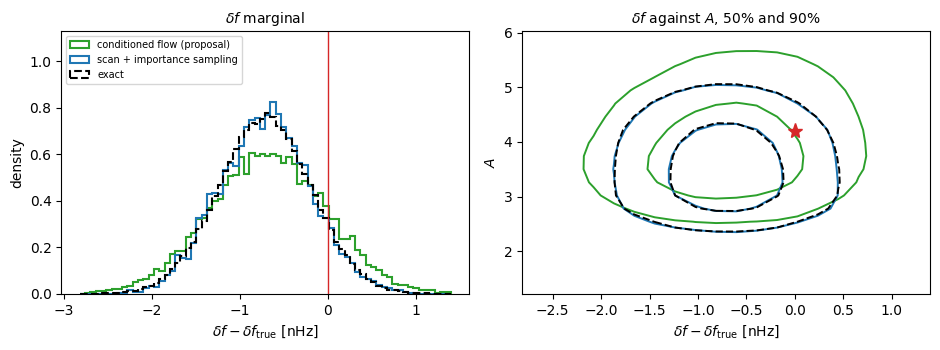

In [23]:
df_c = float(theta_true[0, 1])
sets = [("conditioned flow (proposal)", single, "C2", "-"),
        ("scan + importance sampling", stitched, "C0", "-"),
        ("exact", exact, "k", "--")]

sd_df, sd_A = float(exact[:, 1].std()), float(exact[:, 0].std())
r_df = ((float(exact[:, 1].mean()) - df_c - 4 * sd_df) * 1e9,
        (float(exact[:, 1].mean()) - df_c + 4 * sd_df) * 1e9)
r_A = (float(exact[:, 0].mean()) - 4 * sd_A, float(exact[:, 0].mean()) + 4 * sd_A)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6))
for label, s, c, ls in sets:
    x = ((s[:, 1] - df_c) * 1e9).cpu().numpy()
    axes[0].hist(x, bins=70, range=r_df, density=True, histtype="step",
                 color=c, ls=ls, lw=1.5, label=label)
    corner.hist2d(x, s[:, 0].cpu().numpy(), ax=axes[1], range=[r_df, r_A], levels=(0.5, 0.9),
                  smooth=1.0, plot_datapoints=False, plot_density=False, no_fill_contours=True,
                  color=c, contour_kwargs={"linestyles": ls, "linewidths": 1.4})
axes[0].axvline(0.0, color="C3", lw=1.0)
axes[0].set_ylim(0, axes[0].get_ylim()[1] * 1.30)
axes[0].set_ylabel("density"); axes[0].set_title(r"$\delta f$ marginal", fontsize=10)
axes[0].legend(fontsize=7, loc="upper left")
axes[1].plot(0.0, float(theta_true[0, 0]), "*", color="C3", ms=11)
axes[1].set_ylabel(r"$A$"); axes[1].set_title(r"$\delta f$ against $A$, 50% and 90%", fontsize=10)
for ax in axes:
    ax.set_xlabel(r"$\delta f - \delta f_{\rm true}\ [{\rm nHz}]$")
plt.tight_layout()

The proposal (green) is centered on the right answer and about a quarter too broad in $\delta f$.
Reweighting pulls it onto the exact posterior (black dashed) exactly, at the cost of discarding
most of the draws. Importance sampling does not improve the network; it corrects for the network,
and prices the correction in $\epsilon$.

In [24]:
print(f"{'':>7} {'exact sd':>12} {'naive/exact':>12} {'scan/exact':>11} {'offset [sd]':>12}")
for i, name in enumerate(names):
    s = exact[:, i].std()
    print(f"{name:>7} {s * PLOT_SCALE[i]:12.4g} {naive[:, i].std() / s:12.1f}"
          f" {stitched[:, i].std() / s:11.3f}"
          f" {(stitched[:, i].mean() - exact[:, i].mean()) / s:12.3f}")
print(f"\nwinning tile: epsilon = {eps_final[k_best] * 100:.1f}%, i.e. an effective sample size of "
      f"{eps_final[k_best] * N_FINAL:.0f} from {N_FINAL:,} draws")

            exact sd  naive/exact  scan/exact  offset [sd]
      A       0.6002          2.1       0.991       -0.011
     df    0.0005264         61.5       0.985        0.002
   fdot       0.8182          2.8       0.984        0.001
   phi0      0.09299         13.0       0.993       -0.008
  cos_i       0.1414          4.0       0.993        0.009

winning tile: epsilon = 7.0%, i.e. an effective sample size of 13987 from 200,000 draws


In [25]:
# Control: the same network on a Part 1 observation of the same source -- no conditioning at all.
theta_p1 = theta_true.clone()
theta_p1[:, 1] = theta_p1[:, 1] - DF_HAT[k_best]
torch.manual_seed(11)
d_p1 = signal(theta_p1) + NOISE_STD * torch.randn_like(signal(theta_p1))
with torch.no_grad():
    theta_c, log_q_c = flow_p1.sample_and_log_prob(N_FINAL, d_p1)
theta_c, log_q_c = theta_c[0] * P1_STD + P1_MEAN, log_q_c[0] - torch.log(P1_STD).sum()
inside = ((theta_c > P1_LOW) & (theta_c < P1_HIGH)).all(-1)
log_w_c = torch.where(inside,
                      log_likelihood(theta_c, d_p1) - torch.log(P1_HIGH - P1_LOW).sum() - log_q_c,
                      torch.full_like(log_q_c, -torch.inf))
print(f"epsilon, Part 1 network on Part 1's own problem: {evidence_and_efficiency(log_w_c)[1]:.3f}")
print(f"epsilon, the same network on conditioned data:   {eps_final[k_best]:.3f}")

epsilon, Part 1 network on Part 1's own problem: 0.070
epsilon, the same network on conditioned data:   0.070


Every marginal width agrees with the exact posterior to within two per cent and every mean to
about a hundredth of a standard deviation, from a network trained on a prior twenty times narrower
and never retrained. The model trained *for* this prior is off by a factor of sixty in $\delta f$.

The efficiency is the verdict on the proposal, and the control above says where it comes from. Run
Part 1's network on Part 1's own data, with no demodulation and no band selection, and
$\epsilon = 0.070$ comes back either way, so the conditioning costs no measurable efficiency.
Efficiency belongs to the network and the event together, not to the coordinates the data is
written in: Part 1's own demonstration event returns $\epsilon = 0.11$ from these same weights.
Compare two pipelines on one event, never one pipeline across events. What matters here is that we
know the number, and that the reweighted posterior is exact either way.

---
# 5. P-P plot

<!-- *(~3 min)* -->

Importance sampling checked one event, exactly. The complementary question is whether the credible
intervals are right *on average* over the prior, and Part 1 answered it for the plain network.

Here the object is the whole conditioned pipeline, and section 3 makes that the same measurement:
the proposal in every tile is Part 1's frozen network applied to data distributed exactly as Part
1's, so a P–P plot over Part 1's prior is a statement about every tile of the scan at once. What
the stitching adds is exact by construction, since the tile evidences and the weights both come
from the exact likelihood.

Recall the construction: for each injection, record the quantile of the true value in each
one-dimensional marginal; calibrated posteriors make those quantiles uniform, so their empirical
CDFs follow the diagonal. Four hundred posteriors are four hundred forward passes, affordable only
because the inference is amortized. `pp_plot` is repeated here so this notebook stands alone; the
challenge in section 8 needs it again.

400 posteriors in 29 s
KS p-values: A 0.65  df 0.37  fdot 0.33  phi0 0.94  cos_i 0.60


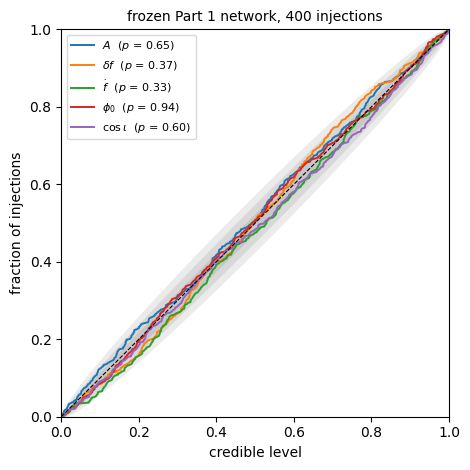

In [26]:
def pp_plot(samples_fn, injections, labels=None, ax=None, confidence=(0.68, 0.95, 0.997)):
    """Probability-probability plot over a set of injections.

    Parameters
    ----------
    samples_fn : callable
        Takes one injection (1, D), simulates an observation of it, and returns
        posterior samples (n, D).
    injections : torch.Tensor
        True parameters, shape (n_inj, D).
    labels : list of str, optional
        One legend label per parameter.
    ax : matplotlib.axes.Axes, optional
        Axes to draw on; a new figure is made if None.
    confidence : tuple of float, optional
        Credible levels of the grey null bands. The k-th order statistic of n uniforms
        is Beta(k, n+1-k), which gives the bands exactly.

    Returns
    -------
    numpy.ndarray
        Quantiles in [0, 1], shape (n_inj, D).
    """
    q = np.stack([(samples_fn(th[None]) < th[None]).float().mean(0).cpu().numpy()
                  for th in injections])
    n, dim = q.shape
    if ax is None:
        _, ax = plt.subplots(figsize=(4.8, 4.8))
    k = np.arange(1, n + 1)
    y = (k - 0.5) / n
    for c in confidence:
        ax.fill_betweenx(y, stats.beta.ppf((1 - c) / 2, k, n + 1 - k),
                         stats.beta.ppf((1 + c) / 2, k, n + 1 - k), color="k", alpha=0.08, lw=0)
    for j in range(dim):
        label = (labels[j] if labels is not None and j < len(labels)
                 else rf"$\theta_{{{j}}}$")
        ax.plot(np.sort(q[:, j]), y, lw=1.4,
                label=f"{label}  ($p$ = {stats.kstest(q[:, j], 'uniform').pvalue:.2f})")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("credible level"); ax.set_ylabel("fraction of injections")
    ax.legend(fontsize=8, loc="upper left")
    return q


def part1_samples(theta, n=2000):
    """Simulate a Part 1 observation of `theta` and return posterior samples from the flow."""
    s = signal(theta)
    with torch.no_grad():
        return flow_p1.sample(n, s + NOISE_STD * torch.randn_like(s))[0] * P1_STD + P1_MEAN


PP_LABELS = [r"$A$", r"$\delta f$", r"$\dot f$", r"$\phi_0$", r"$\cos\iota$",
             r"$\sin\beta$", r"$\lambda$"]        # last two are for the section 8 challenge
PP_NAMES = names + ["sin_beta", "lambda"]

torch.manual_seed(7)
t0 = time.time()
quantiles = pp_plot(part1_samples, sample_prior(400, P1_LOW, P1_HIGH), labels=PP_LABELS)
plt.title("frozen Part 1 network, 400 injections", fontsize=10)
plt.tight_layout()
print(f"400 posteriors in {time.time() - t0:.0f} s")
# Driven by the width of `quantiles`, so a 7-parameter model reports 7 p-values, not 5.
print("KS p-values: " + "  ".join(
    f"{PP_NAMES[i] if i < len(PP_NAMES) else f'param {i}'} "
    f"{stats.kstest(quantiles[:, i], 'uniform').pvalue:.2f}"
    for i in range(quantiles.shape[1])))

Flat, within the bands, for all five parameters. Be careful about what that does and does not say.
It is a statement about the *average* over the prior: a model can pass this test and still return a
poor posterior for the event in front of you. The seven per cent efficiency of section 4 is no
contradiction, because per-event shape errors that scatter in different directions leave the average
coverage intact. A flat P–P plot is not by itself a license to trust one posterior.

P–P for the population, importance sampling for the event in hand. The two diagnostics fail in
different ways, and a result is only defensible with both.

---
# 6. Where this is used

*(~2 min)*

- **The conditioned problem is the problem the network already knows.** The proxy
  $\widehat{\delta f}$ is not a parameter to be learned; it is a coordinate choice. Fixing it turns
  a hard wide-prior problem into the narrow-prior problem you have already solved.
- **Widening the prior adds tiles, not training.** Forty tiles here, milliseconds each, completely
  independent, so the scan parallelizes trivially. As implemented the total cost does grow faster
  than the tile count, because the exact-likelihood pass lengthens with the record as Nyquist
  rises with $W$; a search stage using a band-limited likelihood on the conditioned data would
  select tiles at fixed cost whatever $W$ is, and correctness never depends on that choice, since
  the surviving tiles are importance-sampled against the full likelihood afterwards.
- **It stays amortized.** Nothing here was tuned to this observation. The sequential zoom you saw
  on Monday also recovers accuracy, by retraining around each event; that works, but it gives up
  exactly the property that made NPE attractive for a mission that must analyze tens of thousands
  of sources, repeatedly, as data accumulate.
- **BNS version.** A chirping signal has no fixed band — its track crosses the time–frequency
  plane, and no window of bins contains it — so DINGO-BNS heterodynes by the *model phase*
  instead. The leading term is set by the chirp mass, which straightens the track onto DC and
  only then leaves bandwidth to throw away; scanning a chirp-mass proxy and stitching the tile
  evidences is section 4's algorithm applied to the parameter that dominates the phase there.
  DINGO makes the same move for arrival time: its GNPE networks are handed proxy coalescence
  times, shift the data by them and infer the residual, and the gain appears in sky position and
  the intrinsic parameters rather than in the time, which a matched filter already locates.
  Conditioning on the quantity you can already measure is what lets a network learn the ones you
  cannot, which is the same reason it is worth doing here.

Pushing the prior further sharpens the contrast rather than softening it. Repeating this notebook
at $W = 50$, on the same simulation and epoch budget, the naive wide network's $\delta f$ posterior
comes out 630 to 780 times too wide, while the scan holds 0.96 to 1.02 times the exact widths with
offsets of at most $0.045\sigma$, over 100 tiles, in 41 to 57 s of CPU time in total. (Measured
while this tutorial was built; no checkpoint for it ships here.)

A caveat on the setup. A LISA global fit hands the per-source analysis a box a few frequency bins
wide, so Part 1's narrow prior is not a cheat: it is roughly the realistic situation, and the
widened prior here is a stress test. The hard problem is not where a given source sits but how many
sources there are, and no amount of demodulation answers that. Wednesday's session takes up unknown
source counts.

---
# 7. Exercise — two binaries at once

*(the remainder of the session, or at home)*

Two problems follow, of different sizes. The exercise here is short:
predict first, then complete the cells and compare. The challenge in section 8 is an open project. No
solution is provided for it, it is scored with the P–P test of section 5, and it will take an
afternoon rather than ten minutes.

Of order $10^4$ resolvable galactic binaries share one data stream, so overlap is the normal case
rather than the exception. Add a second source to the data and see what the pipeline does. Where the
interloper falls decides the answer, and the two parts below are the two regimes.

## (a) A binary outside the tile

**Does a second binary outside the retained band reach the posterior?**

Put a faint second source at the far end of the widened prior and re-run the scan; nothing is
retrained. Predict the suppression before you measure it. Block-averaging $R$ samples is a boxcar
filter whose response at a residual frequency $\Delta f$ from the proxy is the Dirichlet kernel
$$
|H(\Delta f)| \;=\; \frac{\bigl|\sin(\pi \Delta f\, T_s)\bigr|}
{R \,\bigl|\sin(\pi \Delta f\, T_s / R)\bigr|},
\qquad T_s = \frac{T_{\rm obs}}{N - 1},
$$
and whatever survives it is aliased into the band. Brick-wall truncation should do far better, and
section 3 left the size of the gap to this exercise. Evaluate the kernel for the interloper, measure
what `condition` achieves against it, and check what is left of the interloper in the recovered
posterior.

In [ ]:
theta_2 = torch.tensor([[2.5, -1.95e-6, 5e-17, 5.0, 0.05]], device=device)
torch.manual_seed(11)
d_two = simulate_wide(theta_true) + signal_wide(theta_2)       # the same noise as d_obs

# YOUR CODE HERE

In [ ]:
# YOUR CODE HERE

k_2 = int((DF_HAT - theta_2[0, 1]).abs().argmin())          # the tile holding source 2
index = np.arange(len(DF_HAT))
far = (np.abs(index - k_best) > 3) & np.isfinite(log_Z_two)  # away from source 1
baseline = np.median(log_Z_two[far & (np.abs(index - k_2) > 1)])

ok2 = np.isfinite(log_Z_two)
y = (log_Z_two - log_Z_two.max())[ok2]
x = DF_HAT.cpu().numpy()[ok2] * 1e6

fig, axes = plt.subplots(2, 1, figsize=(8, 4.4), sharex=True)
for ax in axes:
    ax.plot(x, y, "o-", ms=3, lw=0.8)
    ax.axvline(float(theta_true[0, 1]) * 1e6, color="C3", lw=1.2, label="source 1")
    ax.axvline(float(theta_2[0, 1]) * 1e6, color="C2", lw=1.2, label="source 2")
    ax.set_ylabel(r"$\log Z_k - \max_k \log Z_k$")
faint = (log_Z_two - log_Z_two.max())[far]
axes[1].set_ylim(faint.min() - 10, faint.max() + 12)
axes[0].set_title("the scan sees both binaries", fontsize=10)
axes[1].set_title(f"same curve, zoomed away from source 1: source 2 stands "
                  f"{log_Z_two[k_2] - baseline:.0f} nats above the local baseline", fontsize=10)
axes[0].legend(fontsize=8)
axes[1].set_xlabel(r"tile proxy $\widehat{\delta f}\ [\mu{\rm Hz}]$")
plt.tight_layout()

## (b) A binary inside the tile

**Does anything in the pipeline notice a second source inside the retained band?**

Move the interloper into the *same* tile, where no filter can help, and re-run that tile at the full
sample count. Read $\epsilon$ before you look at the posterior.

In [ ]:
theta_3 = torch.tensor([[3.6, 1.3375e-6 + 1.5e-8, 5e-17, 5.0, -0.2]], device=device)
torch.manual_seed(11)
d_in = simulate_wide(theta_true) + signal_wide(theta_3)
print(f"in-band interloper: SNR {signal_wide(theta_3).pow(2).sum().sqrt():.1f}, "
      f"{float(theta_3[0, 1] - theta_true[0, 1]) * 1e9:+.0f} nHz from the source")

_, eps_b = evidence_and_efficiency(tile_posterior(d_in, k_best, N_FINAL)[1])
print(f"epsilon: {eps_final[k_best]:.2e} (clean) -> {eps_b:.2e} (confused)")

The repair has to happen at training time. Draw 0–2 background binaries and add them to every
training signal, so that the learned posterior marginalizes over confusion instead of pretending it
is absent. One detail decides whether the problem is even well posed. If a background source may be
*louder* than the labelled one, "which source is the answer" has no reply and the network correctly
learns a multimodal mess. Drawing each background amplitude below the labelled source's amplitude
declares the convention, that the source of interest is the loudest, and that is what makes the
target well defined.

`checkpoints/part2a_confusion_flow.pt` is Part 1's flow retrained exactly this way, on the same
100,000 signals for 64 epochs. That is half the epoch budget of the Part 1 checkpoint we have been
using, so treat the two networks' *widths* as only roughly comparable. The quantity the argument
rests on is the pull, which normalizes each posterior by its own width.

In [ ]:
def background_augment(s, a_source, n_max=2):
    """Add 0..n_max background binaries, each fainter than the labelled source. (B, 2N) -> (B, 2N)"""
    # YOUR CODE HERE


class ConfusionDataset(Dataset):
    """Part 1's dataset, with background binaries drawn afresh alongside the noise."""

    def __init__(self, theta, signals):
        self.theta = (theta - P1_MEAN) / P1_STD
        self.amplitude = theta[:, 0:1]           # the augmentation needs physical amplitudes
        self.signals = signals

    def __len__(self):
        return len(self.theta)

    def __getitem__(self, idx):
        s = background_augment(self.signals[idx], self.amplitude[idx])
        return s + NOISE_STD * torch.randn_like(s), self.theta[idx]


TRAIN_LIVE_EX = False            # True -> retrain with augmentation: about 8 min on CPU
EX_CHECKPOINT = "checkpoints/part2a_confusion_flow.pt"

flow_conf = create_flow(num_flow_steps=5, param_dim=5, context_dim=2 * N, hidden_dim=128).to(device)
if TRAIN_LIVE_EX:
    # YOUR CODE HERE
else:
    flow_conf.load_state_dict(
        torch.load(EX_CHECKPOINT, map_location=device, weights_only=False)["state_dict"])
flow_conf.eval();

In [ ]:
def raw_flow_posterior(flow, d, k, n=20_000):
    """Unweighted network output on tile k, mapped back to the wide parameter space."""
    with torch.no_grad():
        theta = flow.sample(n, condition(d, DF_HAT[k]))[0] * P1_STD + P1_MEAN
    theta = theta.clone()
    theta[:, 1] = theta[:, 1] + DF_HAT[k]
    return theta


posteriors = {"clean, Part 1": raw_flow_posterior(flow_p1, d_obs, k_best),
              "clean, augmented": raw_flow_posterior(flow_conf, d_obs, k_best),
              "confused, Part 1": raw_flow_posterior(flow_p1, d_in, k_best),
              "confused, augmented": raw_flow_posterior(flow_conf, d_in, k_best)}

# Quantiles rather than mean and standard deviation: an affine autoregressive flow pushed off its
# training distribution grows heavy tails, and a standard deviation then measures the tails.
q = torch.tensor([0.16, 0.5, 0.84], device=device)
print(f"{'':>6}" + "".join(f"{k:>19}" for k in posteriors))
print(f"{'':>6}" + "".join(f"{'width   pull':>19}" for _ in posteriors))
for i, name in enumerate(names):
    row = ""
    for p in posteriors.values():
        lo, mid, hi = torch.quantile(p[:, i], q)
        width = (hi - lo) / 2
        row += f"{width / exact[:, i].std():12.2f}{(mid - theta_true[0, i]) / width:7.2f}"
    print(f"{name:>6}{row}")
print("\nwidth = half the 16-84% range, in units of the exact posterior's standard deviation"
      "\npull  = (posterior median - truth) / width;  |pull| > 1 puts the truth outside the"
      "\n        posterior's central 68%")

---
# 8. Challenge — free the sky, and meet the simulation-budget wall

No solution ships with this one; the P–P plot of section 5 is how you score it.
Everything above held $(\beta, \lambda)$ fixed and known. The Doppler term in $\Phi(t)$ is what
localizes a source, so freeing them gives a real seven-parameter LISA problem. Take
$\lambda \sim \mathcal{U}[0, 2\pi)$ and $\sin\beta \sim \mathcal{U}[-1, 1]$, uniform on the sphere.
Carry $\sin\beta$, not $\beta$, so the prior stays a box and `sample_prior`, the standardization
and the tile prior keep their form; `torch.rand(n, 5)` becomes `torch.rand(n, 7)`. `BETA` and
`LAM` are module constants inside the waveform (`gb_envelope` in `gb_simulator.py`), so replace
them with columns 5 and 6 of `theta`.

The schematic response depends on $\beta$ only through $\cos\beta$, so the sign of $\beta$ is
exactly unmeasurable: expect a mirror pair of modes at half the mass each, or take
$\sin\beta \sim \mathcal{U}[0, 1]$ and remove them. That is an artifact of the toy antenna pattern,
not of LISA. `reference_posterior` also hard-codes five dimensions.

Budget: Part 1's $10^5$ simulations and 128 epochs, about 16 minutes on a laptop CPU. A bigger flow
will not help. Part 1's rational-quadratic spline reaches a validation loss $1.6$ nats lower and
*fails* the P–P plot; capacity is not the bottleneck, simulations are.

### Deliverables

1. Train the seven-dimensional flow on the *narrow* $\delta f$ prior.
2. A P–P plot on 200 or more held-out injections. Pass is six of seven KS $p$-values above $0.05$
   with none below $0.01$; requiring all seven fails a perfect model three times in ten.
3. Report $\epsilon$, and account for it. It will land near $10^{-4}$ whatever architecture and
   budget you try, against $0.070$ in section 4. Compare your train/validation gap with Part 1's
   $0.10$ nats, and your posterior widths with a Fisher estimate at the truth.
4. Re-run the section 4 scan with the sky free. It still finds the source, by a wider margin than
   section 4's 239 nats; verify that. Then compare the per-tile $\epsilon$ there with section 4's
   and with the unconditioned seven-dimensional problem, and say whether the conditioning or the
   network degraded. Section 3's round-trip check settles it.

The wall is the simulation budget in seven dimensions. Production systems spend millions of
simulations for that reason; this challenge is the small version of the fact.

### References

- Dax et al., [Neural importance sampling for rapid and reliable gravitational-wave inference](https://arxiv.org/abs/2210.05686) (2022)
- Dax et al., [Real-time gravitational-wave inference for binary neutron stars using machine learning](https://arxiv.org/abs/2407.09602) (2024) — the chirp-mass scan in production
- Littenberg & Cornish, [Prototype global analysis of LISA data with multiple source types](https://arxiv.org/abs/2301.03673) (2023) — what a real galactic-binary prior comes from